# What is confusion matrix ?

In [30]:

A confusion matrix is a summary of prediction results on a classification 
problem...


distinguish between cats, dogs and rabbits
27 animals: 8cats, 6dogs, 13rabbits

                            Actual classes
                          Cat    Dog    Rabbit
Predicted Classes   cat    5      2       0
                    Dog    3      3       2
                    Rabbit 0      1       11
                    
 In cat' context
 
                     Actual class
Predicted class      Cat                 Non-cat
                Cat   5 True positive    2 False positive
            Non-Cat    3 False Negative  17 True negative
## Definition of terms:
- Positive: Observation is +ve
- negative : observation  is -ve
- True positive(TP) : Observation(real) is +ve and is predicted to be positive
- False negative(FN): Observation(real) is positive but prediction is -ve
- True negative TN: Observation(real) is -ve but prediction is -ve
- False positive: Observation(real) is -ve but prediction is +ve

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 10)

##  1. Import all Librariy

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [32]:
## load the data
data = pd.read_csv(r"../Dataset/pacific.csv")
data.head()

,ID,Name,Date,Time,Event,Status,Latitude,Longitude,Maximum Wind,Minimum Pressure,...,Low Wind SW,Low Wind NW,Moderate Wind NE,Moderate Wind SE,Moderate Wind SW,Moderate Wind NW,High Wind NE,High Wind SE,High Wind SW,High Wind NW
0,EP011949,UNNAMED,19490611,0,,TS,20.2N,106.3W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
1,EP011949,UNNAMED,19490611,600,,TS,20.2N,106.4W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
2,EP011949,UNNAMED,19490611,1200,,TS,20.2N,106.7W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
3,EP011949,UNNAMED,19490611,1800,,TS,20.3N,107.7W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
4,EP011949,UNNAMED,19490612,0,,TS,20.4N,108.6W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999


## 2. Data Exploration with Graphs and Visualization

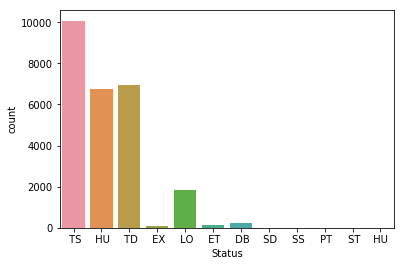

In [33]:
sns.countplot(data['Status'])
plt.show()

In [34]:
# data  wrangling
# data  wrangling, Remove unnecessary column
pred_columns = data[:]
pred_columns.drop(['ID','Name','Event','Status','Latitude','Longitude'],
                 inplace=True,
                 axis=1)
pred_columns.head()


,Date,Time,Maximum Wind,Minimum Pressure,Low Wind NE,Low Wind SE,Low Wind SW,Low Wind NW,Moderate Wind NE,Moderate Wind SE,Moderate Wind SW,Moderate Wind NW,High Wind NE,High Wind SE,High Wind SW,High Wind NW
0,19490611,0,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
1,19490611,600,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
2,19490611,1200,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
3,19490611,1800,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
4,19490612,0,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999


In [35]:
# store the relevant columns
relevant_columns = pred_columns.columns
print(list(relevant_columns))

['Date', 'Time', 'Maximum Wind', 'Minimum Pressure', 'Low Wind NE', 'Low Wind SE', 'Low Wind SW', 'Low Wind NW', 'Moderate Wind NE', 'Moderate Wind SE', 'Moderate Wind SW', 'Moderate Wind NW', 'High Wind NE', 'High Wind SE', 'High Wind SW', 'High Wind NW']


## 3. Building Machine Learning Naive Bayes Models

In [36]:
# split the data
train, test = train_test_split(data, test_size=0.3)
print(train.shape)
print(test.shape)

(18295, 22)
(7842, 22)


In [37]:
train_X = train[relevant_columns]
train_Y = train['Status']

#testing data
test_X = test[relevant_columns]
test_Y = test['Status']


### 3. 1 APPLY Label encoder to convert op category to integer

> In Decision tree and random  forest will supports categorial output. It wont have much difference with label encoding. But still used here

In [38]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
#Or we can use fit_transform instead of separate fit and transform
#le.fit_transform(Y)

# Fit Applied on whole set, few category may miss in train data, so used full
le.fit(data['Status'])
#le.classes_ provides distinct labels
print(" Before Transform" , le.classes_)
##### 0 -->B,  1--->M

#This converts data from  B -->0 aand M to 1   means here its normalized  in 0,1
train_Y = le.transform(train_Y)
train_Y
test_Y = le.transform(test_Y)

#test_Y

 Before Transform [' DB' ' ET' ' EX' ' HU' ' HU ' ' LO' ' PT' ' SD' ' SS' ' ST' ' TD' ' TS']


### 3. 2 APPLY Model

In [39]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

gnb_model = GaussianNB()
gnb_model.fit(train_X, train_Y)

#testing
predicted_op = gnb_model.predict(test_X)


In [40]:
gnb_model.classes_
# To do inverse of classes
test_Y_inv = le.inverse_transform(test_Y)
test_Y_inv

array([' TD', ' TD', ' HU', ..., ' TD', ' TD', ' TD'], dtype=object)

## 4. Model Evaluation

### 4.1 Model Evaluation - Accuracy Score

In [41]:

print("Naive Bayes :" ,accuracy_score(test_Y, predicted_op))


Naive Bayes : 0.058020913032389695


In [49]:
print("Number of mislabeled points out of a total %d points : %d"
%(data.shape[0],(test_Y != predicted_op).sum()))

Number of mislabeled points out of a total 26137 points : 7387


### 4.2. Model Evaluation - confusion_matrix  

In [42]:
from sklearn.metrics import confusion_matrix
# Here labels should be all distinct classes of O/P

cm = confusion_matrix(test_Y, predicted_op )
                    #  , labels= le.classes_)
cm

array([[  66,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,   40,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [   3,   22,    0,    0,    2,    1,    0,    0,    0,    0,    0],
       [   0, 1499,    0,  338,  184,    0,    0,    0,    8,    0,    0],
       [ 519,   40,    0,    0,    8,    0,    3,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,    1,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    2,    0,    0],
       [ 318, 1785,    0,    0,    0,    0,    1,    0,    0,    0,    0],
       [  35, 2417,    0,    0,  545,    0,    3,    1,    0,    1,    0]],
      dtype=int64)

(Text(83.40000000000006, 0.5, 'Predicted'),)

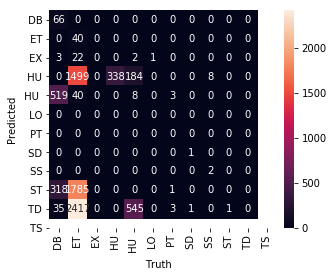

In [48]:
import matplotlib.pyplot as plt

labels = gnb_model.predict(test_X)
mat = confusion_matrix(test_Y, predicted_op)
sns.heatmap(mat,
            fmt='d',
            square=True,
            cbar=True,
            annot=True,
            xticklabels=le.classes_,  # or  np.unique(predicted_op)
            yticklabels=le.classes_)

plt.xlabel('Truth'),
plt.ylabel('Predicted'),


### 4.3. Model Evaluation - classification_report  

In [47]:
# classification_report

# Here we need to give categorial value instead of label encoded value. It will be easy to interpretate
print("Naive Bayesconfusion_matrix :" ,classification_report(test_Y, predicted_op))


Naive Bayesconfusion_matrix :               precision    recall  f1-score   support

           0       0.07      1.00      0.13        66
           1       0.01      1.00      0.01        40
           2       0.00      0.00      0.00        28
           3       1.00      0.17      0.29      2029
           5       0.01      0.01      0.01       570
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.50      1.00      0.67         1
           9       0.20      1.00      0.33         2
          10       0.00      0.00      0.00      2104
          11       0.00      0.00      0.00      3002

   micro avg       0.06      0.06      0.06      7842
   macro avg       0.16      0.38      0.13      7842
weighted avg       0.26      0.06      0.08      7842



C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1145: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples.
  'recall', 'true', average, warn_for)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1145: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples.
  'recall', 'true', average, warn_for)
C:\Users\prabh\Anaconda3\lib\sit

# The confusion matrix is best used for binary evaluation.For multi class it wont give much clarity, we should go with other evaluation method

#### Below not working, library are not installed here

NameError: name 'np' is not defined

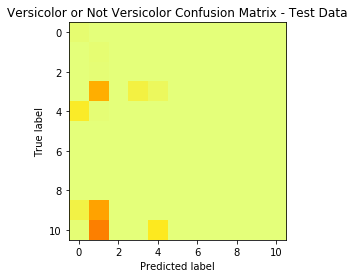

In [31]:
# To plot Confusion matrix. Below for 2 class, but not working here
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = le.classes_ #['Negative','Positive']
plt.title('Versicolor or Not Versicolor Confusion Matrix - Test Data')
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['TN','FP'], ['FN', 'TP']]  # This needs to be full list of hurricane
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()


In [14]:
# To plot Confusion matrix. But not working here
from sklearn.metrics import plot_confusion_matrix
import matplotlib.pyplot as plt 

plot_confusion_matrix(gnb_model, test_X, test_Y)  
plt.show()

ImportError: cannot import name 'plot_confusion_matrix' from 'sklearn.metrics' (C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\__init__.py)

In [29]:
# To plot Confusion matrix. But not working here
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_Y, predicted_op, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=clf.classes_)
disp.plot() 

ImportError: cannot import name 'ConfusionMatrixDisplay' from 'sklearn.metrics' (C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\__init__.py)